In [1]:
from glob import glob
import pandas as pd
DATA_DIR = "/DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/deepctrl-sft-data/sft_data_zh.jsonl"
from tqdm import tqdm
import json
import re
import random


In [2]:
# 读取数据集并统计type_keyword
# 注意：type_keyword是一个列表，需要对列表中的每个关键词进行统计
type_keyword_count = {}  # 用于统计每个type_keyword的出现次数

print("开始读取数据集并统计type_keyword...")

with open(DATA_DIR, 'r', encoding='utf-8') as file:
    for idx, line in enumerate(tqdm(file, desc="处理数据")):
        try:
            # 解析JSON数据
            json_obj = json.loads(line)
            
            # 提取type_keyword字段
            keyword_list = json_obj.get("type_keyword", "")
            
            for keyword in keyword_list:
            # 如果type_keyword不为空，则进行统计
                if keyword in type_keyword_count:
                    type_keyword_count[keyword] += 1
                else:
                    type_keyword_count[keyword] = 1
        except json.JSONDecodeError:
            # 如果某行JSON格式有问题，跳过该行
            print(f"第{idx+1}行JSON格式错误，跳过")
            continue

# 显示统计结果
print(f"\n总共找到 {len(type_keyword_count)} 种不同的type_keyword")
print("\ntype_keyword统计结果:")
print("-" * 50)

# 按出现次数降序排列显示结果
sorted_keywords = sorted(type_keyword_count.items(), key=lambda x: x[1], reverse=True)
for keyword, count in sorted_keywords:
    print(f"{keyword}: {count} 次")

print(f"\n总数据条数: {sum(type_keyword_count.values())}")


开始读取数据集并统计type_keyword...


处理数据: 11381621it [01:52, 101211.38it/s]


总共找到 228 种不同的type_keyword

type_keyword统计结果:
--------------------------------------------------
生成: 5438851 次
文本: 4287118 次
进行: 4037318 次
问题: 3996544 次
给出: 3256338 次
提供: 3221853 次
给定: 3066849 次
描述: 2717345 次
主题: 2284078 次
句子: 2262185 次
文章: 1984854 次
包括: 1783154 次
公司: 1686354 次
回答: 1641512 次
编写: 1543974 次
介绍: 1472360 次
喜欢: 1443800 次
需要: 1239049 次
答案: 1002818 次
应用: 934079 次
对话: 930038 次
建议: 928281 次
使用: 908274 次
帮助: 845304 次
计算: 844689 次
有关: 838570 次
输入: 838389 次
实现: 787638 次
设计: 762480 次
信息: 761437 次
是否: 701248 次
工作: 691029 次
列表: 650764 次
撰写: 629312 次
内容: 624434 次
解释: 589247 次
影响: 581504 次
提高: 565189 次
方法: 565189 次
人工智能: 551934 次
技术: 551934 次
表达: 534899 次
分类: 532382 次
故事: 515566 次
小说: 515566 次
分析: 515560 次
段落: 515432 次
语言: 509842 次
美国: 507563 次
实体: 506178 次
学习: 502557 次
产品: 500264 次
单词: 493823 次
代码: 492183 次
函数: 492183 次
程序: 492183 次
编辑: 489314 次
重写: 489314 次
语法: 489314 次
改写: 489314 次
短文: 474892 次
数字: 472991 次
数据: 465783 次
表格: 465783 次
数学题: 462229 次
小学: 462229 次
解决: 457308 次
科技: 457100

In [3]:
# 定义分组策略
group_keywords = {
    "Safety and Ethical Alignment": ["不会", "不能", "歧视", "负面", "消极", "有害", "危险", "违法"],
    "Code and Programming": ["代码", "函数", "程序", "编程", "实现", "算法", "设计"],
    "Math & Logic Reasoning": ["数学", "数学题", "计算", "推理", "排序", "数字", "整数", "平均值", "题目", "解决"],
    "Translation": ["翻译", "目标语言"],
    "Text Rewriting & Editing": ["编辑", "重写", "改写", "语法", "润色", "风格", "同义词", "续写"],
    "Text Processing & Info Extraction": ["摘要", "提取", "总结", "分类", "分析", "判断", "情感", "识别", "实体"],
    "Knowledge Q&A & Explanation": ["问题", "回答", "答案", "解释", "介绍", "说明", "概念", "原理", "知道", "请问", "是什么"],
    "Domain Knowledge Application": ["旅游", "餐厅", "美食", "菜谱", "食谱", "烹饪", "装修", "天气", "医疗", "疾病", "医生", "药物", "健身", "饮食", "人工智能", "技术", "公司", "产品", "品牌", "历史", "中国", "美国", "电影", "爱情"],
    "Role-playing & General Dialogue": ["对话", "角色", "认为", "经验", "朋友", "讲述", "喜欢"],
    # 注意：通用生成类别作为最后的默认选项
    "General Generation & Creation": ["生成", "编写", "创作", "撰写", "开头", "故事", "小说", "诗歌", "古诗", "对联", "歌词", "文案", "标题", "文章", "短文", "段落", "句子", "内容"]
}
        #"安全与伦理对齐"
        #"代码与编程", 
        #"数学与逻辑推理",
        #"翻译",
        #"文本改写与编辑",
        #"文本处理与信息提取",
        #"知识问答与解释",
        #"领域知识应用",
        #"角色扮演与通用对话",
        #"通用生成与创作"
print("开始根据关键词分组数据...")
print("=" * 60)

# 初始化每个分组的数据存储
grouped_data = {group_name: [] for group_name in group_keywords.keys()}
unclassified_data = []  # 存储无法分类的数据


# 重新读取原始数据进行分组
with open(DATA_DIR, 'r', encoding='utf-8') as file:
    for idx, line in enumerate(tqdm(file, desc="分组处理数据")):
        try:
            # 解析JSON数据
            json_obj = json.loads(line)
            
            # 检查必要字段是否存在且有效
            if json_obj.get("input", "") == "" or json_obj.get("output", "") == "":
                continue
            
            # 提取type_keyword字段
            keyword_list = json_obj.get("type_keyword", [])
            
            # 判断该数据属于哪个分组
            data_classified = False
            
            # 遍历每个分组，检查是否包含对应关键词
            for group_name, keywords in group_keywords.items():
                # 检查数据的关键词列表是否与当前分组的关键词有交集
                if any(keyword in keyword_list for keyword in keywords):
                    grouped_data[group_name].append(json_obj)
                    data_classified = True
                    break  # 找到第一个匹配的分组就停止
            
            # 如果没有找到匹配的分组，放入未分类数据
            if not data_classified:
                unclassified_data.append(json_obj)
                
        except json.JSONDecodeError:
            # 如果某行JSON格式有问题，跳过该行
            print(f"第{idx+1}行JSON格式错误，跳过")
            continue

# 显示分组统计结果
print("\n数据分组统计结果:")
print("=" * 60)
total_classified = 0

for group_name, data_list in grouped_data.items():
    count = len(data_list)
    total_classified += count
    print(f"{group_name}: {count} 条数据")

print(f"未分类数据: {len(unclassified_data)} 条")
print(f"总分类数据: {total_classified} 条")
print(f"总数据量: {total_classified + len(unclassified_data)} 条")

# # 保存分组后的数据到不同文件
# print("\n开始保存分组数据到文件...")
# print("-" * 50)

# for group_name, data_list in grouped_data.items():
#     if len(data_list) > 0:  # 只保存非空分组
#         # 创建文件名（将中文分组名转换为英文文件名）
#         filename_mapping = {
#             "文本生成与创作": "generation_creation",
#             "知识问答与解释": "qa_explanation", 
#             "代码与编程": "code_programming",
#             "数学与逻辑推理": "math_reasoning",
#             "文本处理与信息提取": "text_processing_ie",
#             "文本改写与编辑": "rewriting_editing",
#             "翻译": "translation",
#             "角色扮演与对话": "roleplay_dialogue",
#             "安全与伦理对齐": "safety_ethics",
#             "领域知识应用": "domain_application"
#         }
        
#         filename = filename_mapping.get(group_name, group_name.replace(" ", "_").lower())
#         output_file = f"grouped_data_{filename}.jsonl"
        
#         # 保存数据到文件
#         with open(output_file, 'w', encoding='utf-8') as f:
#             for item in data_list:
#                 f.write(json.dumps(item, ensure_ascii=False) + '\n')
        
#         print(f"已保存 {group_name} 数据到文件: {output_file} ({len(data_list)} 条)")

# # 保存未分类数据
# if len(unclassified_data) > 0:
#     with open("grouped_data_unclassified.jsonl", 'w', encoding='utf-8') as f:
#         for item in unclassified_data:
#             f.write(json.dumps(item, ensure_ascii=False) + '\n')
#     print(f"已保存未分类数据到文件: grouped_data_unclassified.jsonl ({len(unclassified_data)} 条)")

# print("\n数据分组和保存完成！")


开始根据关键词分组数据...


分组处理数据: 11381621it [04:35, 41386.36it/s] 


数据分组统计结果:
安全与伦理对齐: 402984 条数据
代码与编程: 1239483 条数据
数学与逻辑推理: 2021731 条数据
翻译: 354986 条数据
文本改写与编辑: 1042574 条数据
文本处理与信息提取: 1657610 条数据
知识问答与解释: 2507034 条数据
领域知识应用: 1626117 条数据
角色扮演与通用对话: 220684 条数据
通用生成与创作: 131138 条数据
未分类数据: 0 条
总分类数据: 11204341 条
总数据量: 11204341 条


In [14]:
# 保存分组后的数据到不同文件
print("\n开始保存分组数据到文件...")
print("-" * 50)

for group_name, data_list in grouped_data.items():
    if len(data_list) > 0:  # 只保存非空分组
        # 创建文件名（将中文分组名转换为英文文件名）
        filename_mapping = {
            "文本生成与创作": "generation_creation",
            "知识问答与解释": "qa_explanation", 
            "代码与编程": "code_programming",
            "数学与逻辑推理": "math_reasoning",
            "文本处理与信息提取": "text_processing_ie",
            "文本改写与编辑": "rewriting_editing",
            "翻译": "translation",
            "角色扮演与对话": "roleplay_dialogue",
            "安全与伦理对齐": "safety_ethics",
            "领域知识应用": "domain_application"
        }
        
        filename = filename_mapping.get(group_name, group_name.replace(" ", "_").lower())
        output_file = f"/DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_{filename}.jsonl"
        
        # 保存数据到文件
        with open(output_file, 'w', encoding='utf-8') as f:
            for item in data_list:
                f.write(json.dumps(item, ensure_ascii=False) + '\n')
        
        print(f"已保存 {group_name} 数据到文件: {output_file} ({len(data_list)} 条)")

# 保存未分类数据
if len(unclassified_data) > 0:
    with open("grouped_data_unclassified.jsonl", 'w', encoding='utf-8') as f:
        for item in unclassified_data:
            f.write(json.dumps(item, ensure_ascii=False) + '\n')
    print(f"已保存未分类数据到文件: grouped_data_unclassified.jsonl ({len(unclassified_data)} 条)")

print("\n数据分组和保存完成！")



开始保存分组数据到文件...
--------------------------------------------------
已保存 安全与伦理对齐 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_safety_ethics.jsonl (402984 条)
已保存 代码与编程 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_code_programming.jsonl (1239483 条)
已保存 数学与逻辑推理 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_math_reasoning.jsonl (2021731 条)
已保存 翻译 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_translation.jsonl (354986 条)
已保存 文本改写与编辑 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_rewriting_editing.jsonl (1042574 条)
已保存 文本处理与信息提取 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_text_processing_ie.jsonl (1657610 条)
已保存 知识问答与解释 数据到文件: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_qa_explanation.jsonl (2

In [1]:
# 读取翻译数据集文件并检查instruction列
import json
import os

translation_file = "/DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_translation.jsonl"

print("开始检查翻译数据集文件...")
print("-" * 50)

# 检查文件是否存在
if not os.path.exists(translation_file):
    print(f"错误：文件不存在 - {translation_file}")
else:
    print(f"文件存在，开始读取: {translation_file}")
    
    # 统计变量
    total_count = 0           # 总数据条数
    has_instruction = 0       # 有instruction字段的条数
    empty_instruction = 0     # instruction字段为空的条数
    valid_instruction = 0     # instruction字段有有效内容的条数
    
    # 存储一些示例数据用于展示
    sample_data = []
    
    try:
        with open(translation_file, 'r', encoding='utf-8') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:  # 跳过空行
                    continue
                    
                try:
                    # 解析JSON数据
                    data = json.loads(line)
                    total_count += 1
                    
                    # 检查是否有instruction字段
                    if 'instruction' in data:
                        has_instruction += 1
                        instruction_content = data['instruction']
                        
                        # 检查instruction内容是否为空
                        if not instruction_content or (isinstance(instruction_content, str) and instruction_content.strip() == ""):
                            empty_instruction += 1
                        else:
                            valid_instruction += 1
                            
                        # 收集前5个样本用于展示
                        if len(sample_data) < 5:
                            sample_data.append({
                                'line_num': line_num,
                                'instruction': instruction_content,
                                'has_output': 'output' in data,
                                'output_preview': data.get('output', '')[:100] + '...' if data.get('output') else None
                            })
                    
                    # 每处理10000条数据显示一次进度
                    if total_count % 10000 == 0:
                        print(f"已处理 {total_count} 条数据...")
                        
                except json.JSONDecodeError as e:
                    print(f"第 {line_num} 行JSON解析错误: {e}")
                    continue
                    
    except Exception as e:
        print(f"读取文件时发生错误: {e}")
    
    # 输出统计结果
    print("\n" + "="*60)
    print("翻译数据集检查结果:")
    print("="*60)
    print(f"总数据条数: {total_count:,}")
    print(f"包含instruction字段的条数: {has_instruction:,}")
    print(f"instruction字段为空的条数: {empty_instruction:,}")
    print(f"instruction字段有有效内容的条数: {valid_instruction:,}")
    
    if total_count > 0:
        print(f"\n百分比统计:")
        print(f"包含instruction字段: {has_instruction/total_count*100:.2f}%")
        if has_instruction > 0:
            print(f"instruction为空: {empty_instruction/has_instruction*100:.2f}%")
            print(f"instruction有效: {valid_instruction/has_instruction*100:.2f}%")
    
    # 显示样本数据
    if sample_data:
        print(f"\n前{len(sample_data)}个样本数据预览:")
        print("-" * 60)
        for i, sample in enumerate(sample_data, 1):
            print(f"样本 {i} (第{sample['line_num']}行):")
            print(f"  instruction: {repr(sample['instruction'][:200])}{'...' if len(str(sample['instruction'])) > 200 else ''}")
            print(f"  有output字段: {sample['has_output']}")
            if sample['output_preview']:
                print(f"  output预览: {repr(sample['output_preview'])}")
            print()


开始检查翻译数据集文件...
--------------------------------------------------
文件存在，开始读取: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_translation.jsonl
已处理 10000 条数据...
已处理 20000 条数据...
已处理 30000 条数据...
已处理 40000 条数据...
已处理 50000 条数据...
已处理 60000 条数据...
已处理 70000 条数据...
已处理 80000 条数据...
已处理 90000 条数据...
已处理 100000 条数据...
已处理 110000 条数据...
已处理 120000 条数据...
已处理 130000 条数据...
已处理 140000 条数据...
已处理 150000 条数据...
已处理 160000 条数据...
已处理 170000 条数据...
已处理 180000 条数据...
已处理 190000 条数据...
已处理 200000 条数据...
已处理 210000 条数据...
已处理 220000 条数据...
已处理 230000 条数据...
已处理 240000 条数据...
已处理 250000 条数据...
已处理 260000 条数据...
已处理 270000 条数据...
已处理 280000 条数据...
已处理 290000 条数据...
已处理 300000 条数据...
已处理 310000 条数据...
已处理 320000 条数据...
已处理 330000 条数据...
已处理 340000 条数据...
已处理 350000 条数据...

翻译数据集检查结果:
总数据条数: 354,986
包含instruction字段的条数: 354,986
instruction字段为空的条数: 262,377
instruction字段有有效内容的条数: 92,609

百分比统计:
包含instruction字段: 100.00%
instruction为空: 73.91%
instruction有效: 26.09%

前5个样本数据预览:

类别合并完成！
通用文本处理类别包含 7,185,157 条数据 (64.1%)
合并后共有 5 个类别


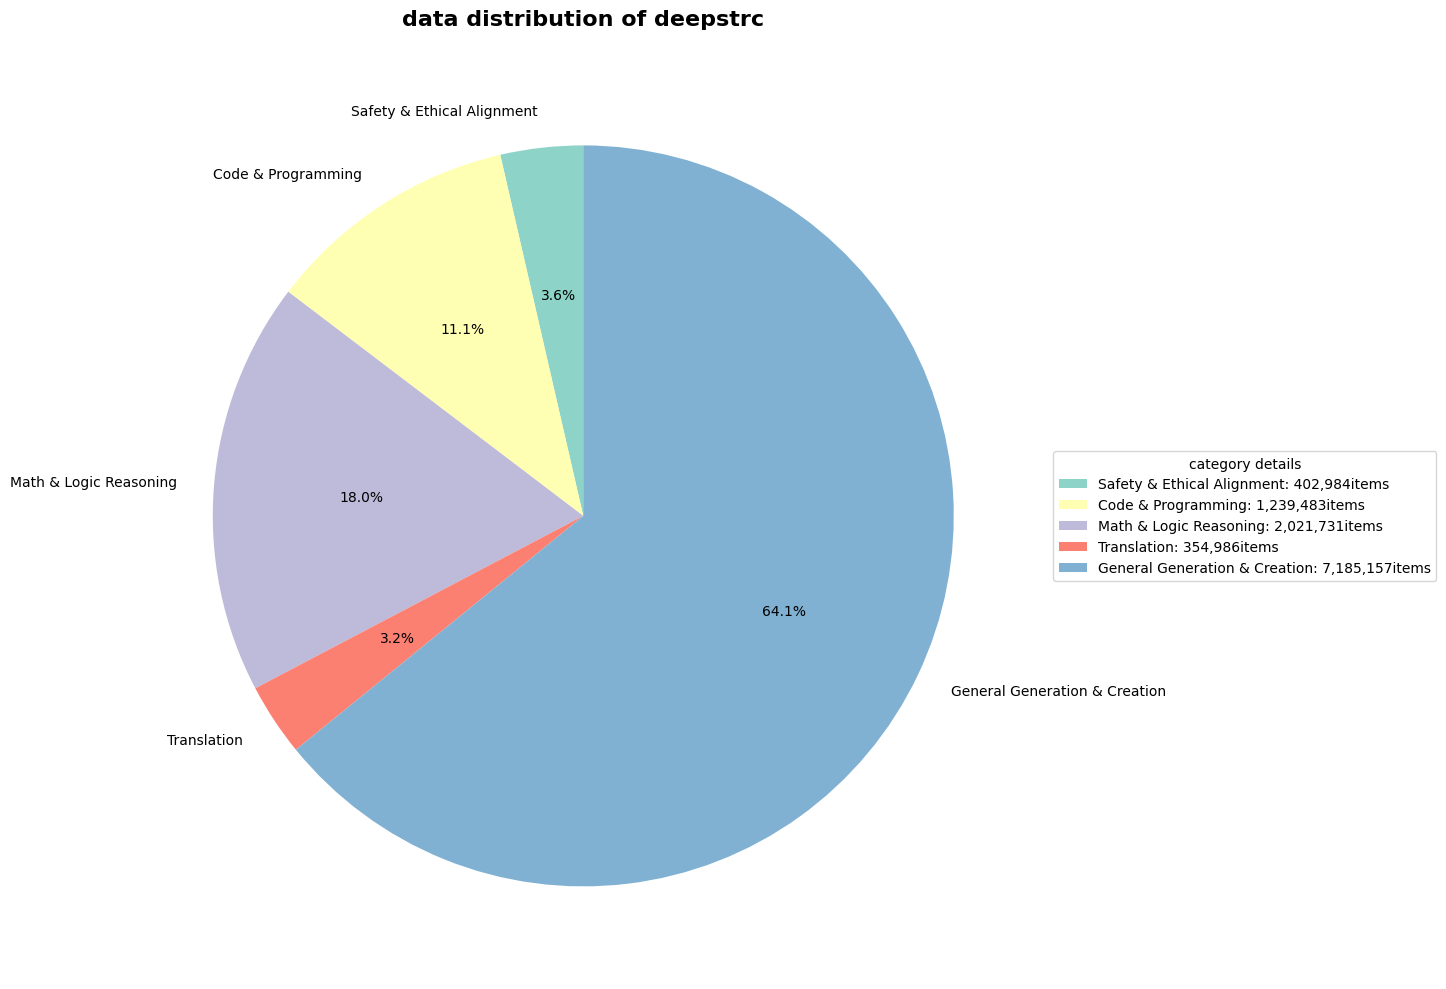

数据分类统计:
--------------------------------------------------
Safety & Ethical Alignment: 402,984 条数据 (3.6%)
Code & Programming: 1,239,483 条数据 (11.1%)
Math & Logic Reasoning: 2,021,731 条数据 (18.0%)
Translation: 354,986 条数据 (3.2%)
General Generation & Creation: 7,185,157 条数据 (64.1%)

总数据量: 11,204,341 条
最大分类: General Generation & Creation (7,185,157 items)
最小分类: Translation (354,986 items)


In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 设置中文字体支持
plt.rcParams['font.sans-serif'] = ['WenQuanYi Zen Hei', 'SimHei', 'DejaVu Sans']  # 使用黑体或DejaVu Sans
plt.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 数据分类结果
categories = [
    "Safety & Ethical Alignment",       #"安全与伦理对齐"
    "Code & Programming",               #"代码与编程", 
    "Math & Logic Reasoning",           #"数学与逻辑推理",
    "Translation",                      #"翻译",
    "Text Rewriting & Editing",         #"文本改写与编辑",
    "Text Processing & Info Extraction",#"文本处理与信息提取",
    "Knowledge Q&A & Explanation",      #"知识问答与解释",
    "Domain Knowledge Application",     #"领域知识应用",
    "Role-playing & General Dialogue",  #"角色扮演与通用对话",
    "General Generation & Creation"     #"通用生成与创作"
]
    
# 对应的数据量
data_counts = [
    402984,   # 安全与伦理对齐
    1239483,  # 代码与编程
    2021731,  # 数学与逻辑推理
    354986,   # 翻译
    1042574,  # 文本改写与编辑
    1657610,  # 文本处理与信息提取
    2507034,  # 知识问答与解释
    1626117,  # 领域知识应用
    220684,   # 角色扮演与通用对话
    131138    # 通用生成与创作
]

# 计算百分比
total_data = sum(data_counts)
percentages = [count/total_data*100 for count in data_counts]

# 将指定的类别合并为"通用文本处理"
merge_categories = [
            "Text Rewriting & Editing",   #"文本改写与编辑",
            "Text Processing & Info Extraction",  #"文本处理与信息提取",
            "Knowledge Q&A & Explanation",          #"知识问答与解释",
            "Domain Knowledge Application",         #"领域知识应用",
            "Role-playing & General Dialogue",       #"角色扮演与通用对话",
            "General Generation & Creation"    #"通用生成与创作"
]

# 找到需要合并的类别索引和对应的数据量
merge_indices = []
merge_counts = []
for i, category in enumerate(categories):
    if category in merge_categories:
        merge_indices.append(i)
        merge_counts.append(data_counts[i])

# 计算合并后的数据量
merged_count = sum(merge_counts)

# 创建新的类别列表和数据量列表
new_categories = []
new_data_counts = []

# 添加不需要合并的类别
for i, category in enumerate(categories):
    if category not in merge_categories:
        new_categories.append(category)
        new_data_counts.append(data_counts[i])

# 添加合并后的新类别
new_categories.append("General Generation & Creation")
new_data_counts.append(merged_count)

# 更新用于绘图的数据
categories = new_categories
data_counts = new_data_counts

# 重新计算百分比
total_data = sum(data_counts)
percentages = [count/total_data*100 for count in data_counts]

print("类别合并完成！")
print(f"通用文本处理类别包含 {merged_count:,} 条数据 ({merged_count/total_data*100:.1f}%)")
print(f"合并后共有 {len(categories)} 个类别")

# 创建饼状图
plt.figure(figsize=(12, 10))

# 设置颜色方案
colors = plt.cm.Set3(range(len(categories)))

# 绘制饼状图
wedges, texts, autotexts = plt.pie(
    data_counts, 
    labels=categories,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    textprops={'fontsize': 10}
)

# 设置标题
plt.title('data distribution of deepstrc', fontsize=16, fontweight='bold', pad=20)

# 调整布局，确保标签不被截断
plt.tight_layout()

# 添加图例，显示具体数量
legend_labels = [f'{cat}: {count:,}items' for cat, count in zip(categories, data_counts)]
plt.legend(wedges, legend_labels, title="category details", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))

# 显示图表
plt.show()

# 打印统计信息
print("数据分类统计:")
print("-" * 50)
for i, (category, count) in enumerate(zip(categories, data_counts)):
    percentage = percentages[i]
    print(f"{category}: {count:,} 条数据 ({percentage:.1f}%)")

print(f"\n总数据量: {total_data:,} 条")
print(f"最大分类: {categories[data_counts.index(max(data_counts))]} ({max(data_counts):,} items)")
print(f"最小分类: {categories[data_counts.index(min(data_counts))]} ({min(data_counts):,} items)")


In [10]:
def convert_to_llama_factory_format(item):
    """
    将SFT数据格式转换为llama-factory格式
    原格式：instruction为空，input包含任务描述，output包含生成内容
    转换后：instruction包含任务描述，input为空，output保持不变
    """
    return {
        "instruction": item["input"],
        "input": "",
        "output": item["output"].strip()
    }

all_data = []
token_num_list = []

with open(DATA_DIR, 'r', encoding='utf-8') as file:
    for idx, line in enumerate(file):
        # 解码JSON对象
        json_obj = json.loads(line)
        
        # 检查必要字段是否存在且有效
        if json_obj.get("input", "") == "" or json_obj.get("output", "") == "":
            continue
            
        # 转换为llama-factory格式
        converted_data = convert_to_llama_factory_format(json_obj)
        all_data.append(converted_data)
        token_num_list.append(len(converted_data))

print(f"总共处理了 {len(all_data)} 条数据")
print(len(token_num_list))

# 显示转换后的数据示例
if all_data:
    print("转换后的数据示例:")
    print(all_data[0])

总共处理了 11204341 条数据
11204341
转换后的数据示例:
{'instruction': '好的。现在请你将这个文本中的所有的逗号都替换成空格。', 'input': '', 'output': '好的，请稍等一下，现在我会将文本中的所有逗号替换为空格。处理后文本为："这是一个句子 目的是看看是否可以正确地从这个句子中删除关键词。"。处理结果如何？'}


In [11]:
import numpy as np
np.percentile(token_num_list,[50, 60, 70, 80, 90,95,99])
print(np.percentile(token_num_list,[50, 60, 70, 80, 90,95, 99]))
filtered_long_data = []
filtered_token_num = []
for i in range(len(all_data)):
    if token_num_list[i] < 768:
        filtered_long_data.append(all_data[i])
        filtered_token_num.append(token_num_list[i])
print(np.percentile(filtered_token_num,[50, 60, 70, 80, 90,95, 99]))
print(len(filtered_token_num))

[3. 3. 3. 3. 3. 3. 3.]
[3. 3. 3. 3. 3. 3. 3.]
11204341


In [12]:
few_data = random.sample(filtered_long_data, len(filtered_long_data))
print(f"采样后数据量: {len(few_data)}")

采样后数据量: 11204341


In [13]:
import os
file_path = "/DATA/disk2/yuhang/.cache/steel_dataset/sft_data/llamafactory_input/deepctl_1120W.jsonl"

directory = os.path.dirname(file_path)

if not os.path.exists(directory):
    os.makedirs(directory)
    print(f"目录{directory} 不存在，已创建")
else:
    print(f"目录{directory} 已存在")

with open(file_path, 'w', encoding="utf-8") as f:
    for item in few_data:
        json.dump(item, f, ensure_ascii=False)
        f.write('\n')

print(f"数据已保存到: {file_path}")

目录/DATA/disk2/yuhang/.cache/steel_dataset/sft_data/llamafactory_input 已存在
数据已保存到: /DATA/disk2/yuhang/.cache/steel_dataset/sft_data/llamafactory_input/deepctl_1120W.jsonl


In [1]:
# 打开并过滤数据集文件，只保留英文和中文数据
import json
import re

def detect_language(text):
    """
    检测文本语言，返回 'zh' (中文), 'en' (英文), 或 'other' (其他语言)
    """
    if not text or not isinstance(text, str):
        return 'other'
    
    # 统计中文字符数量
    chinese_chars = len(re.findall(r'[\u4e00-\u9fff]', text))
    # 统计英文字符数量（字母）
    english_chars = len(re.findall(r'[a-zA-Z]', text))
    # 总字符数（排除空格和标点）
    total_chars = chinese_chars + english_chars
    
    if total_chars == 0:
        return 'other'
    
    # 如果中文字符占比超过30%，认为是中文
    if chinese_chars / total_chars > 0.3:
        return 'zh'
    # 如果英文字符占比超过70%，认为是英文
    elif english_chars / total_chars > 0.7:
        return 'en'
    else:
        return 'other'

# 读取原始数据文件
input_file = "/DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/classification/grouped_data_translation.jsonl"
filtered_data = []
language_stats = {'zh': 0, 'en': 0, 'other': 0}

print("开始读取和过滤数据...")

try:
    with open(input_file, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            try:
                # 解析JSON数据
                data = json.loads(line.strip())
                
                # 检测指令和输出的语言
                instruction_lang = 'other'
                output_lang = 'other'
                
                # 检查不同可能的字段名
                if 'instruction' in data:
                    instruction_lang = detect_language(data['instruction'])
                elif 'prompt' in data:
                    instruction_lang = detect_language(data['prompt'])
                elif 'input' in data:
                    instruction_lang = detect_language(data['input'])
                
                if 'output' in data:
                    output_lang = detect_language(data['output'])
                elif 'response' in data:
                    output_lang = detect_language(data['response'])
                elif 'answer' in data:
                    output_lang = detect_language(data['answer'])
                
                # 只保留中文或英文数据（指令和输出都必须是中文或英文）
                if (instruction_lang in ['zh', 'en']) and (output_lang in ['zh', 'en']):
                    filtered_data.append(data)
                    # 统计语言分布（以指令语言为准）
                    language_stats[instruction_lang] += 1
                else:
                    language_stats['other'] += 1
                
                # 每处理10万条数据显示一次进度
                if line_num % 10000 == 0:
                    print(f"已处理 {line_num} 条数据，当前保留 {len(filtered_data)} 条")
                    
            except json.JSONDecodeError as e:
                print(f"第 {line_num} 行JSON解析错误: {e}")
                continue
            except Exception as e:
                print(f"第 {line_num} 行处理错误: {e}")
                continue

except FileNotFoundError:
    print(f"文件未找到: {input_file}")
except Exception as e:
    print(f"读取文件时出错: {e}")

print(f"\n数据过滤完成！")
print(f"原始数据总数: {sum(language_stats.values())}")
print(f"过滤后数据总数: {len(filtered_data)}")
print(f"语言分布统计:")
print(f"  中文数据: {language_stats['zh']} 条")
print(f"  英文数据: {language_stats['en']} 条") 
print(f"  其他语言数据（已过滤）: {language_stats['other']} 条")

# 显示几个过滤后的数据示例
if filtered_data:
    print(f"\n过滤后的数据示例:")
    for i, example in enumerate(filtered_data[:3]):
        print(f"示例 {i+1}:")
        print(f"  数据结构: {list(example.keys())}")
        # 显示前100个字符
        for key, value in example.items():
            if isinstance(value, str) and len(value) > 100:
                print(f"  {key}: {value[:100]}...")
            else:
                print(f"  {key}: {value}")
        print()


开始读取和过滤数据...
已处理 10000 条数据，当前保留 0 条
已处理 20000 条数据，当前保留 0 条
已处理 30000 条数据，当前保留 0 条
已处理 40000 条数据，当前保留 0 条
已处理 50000 条数据，当前保留 0 条
已处理 60000 条数据，当前保留 0 条
已处理 70000 条数据，当前保留 0 条
已处理 80000 条数据，当前保留 6554 条
已处理 90000 条数据，当前保留 15963 条
已处理 100000 条数据，当前保留 23888 条
已处理 110000 条数据，当前保留 33271 条
已处理 120000 条数据，当前保留 42498 条
已处理 130000 条数据，当前保留 51714 条
已处理 140000 条数据，当前保留 60986 条
已处理 150000 条数据，当前保留 70015 条
已处理 160000 条数据，当前保留 70544 条
已处理 170000 条数据，当前保留 70544 条
已处理 180000 条数据，当前保留 70544 条
已处理 190000 条数据，当前保留 70544 条
已处理 200000 条数据，当前保留 70544 条
已处理 210000 条数据，当前保留 70544 条
已处理 220000 条数据，当前保留 70544 条
已处理 230000 条数据，当前保留 70544 条
已处理 240000 条数据，当前保留 70544 条
已处理 250000 条数据，当前保留 70761 条
已处理 260000 条数据，当前保留 72997 条
已处理 270000 条数据，当前保留 72997 条
已处理 280000 条数据，当前保留 72997 条
已处理 290000 条数据，当前保留 72997 条
已处理 300000 条数据，当前保留 72997 条
已处理 310000 条数据，当前保留 72997 条
已处理 320000 条数据，当前保留 72997 条
已处理 330000 条数据，当前保留 72997 条
已处理 340000 条数据，当前保留 81771 条
已处理 350000 条数据，当前保留 85913 条

数据过滤完成！
原始数据总数: 354986
过滤后数据总数: 85913
语言分布统计

In [4]:
# 保存过滤后的数据
import os
import json

# 设置保存目录
output_dir = "/DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/fliter"
os.makedirs(output_dir, exist_ok=True)

# 保存为JSONL格式
output_file = os.path.join(output_dir, "deepctrl_filtered_zh_en.jsonl")

print(f"正在保存过滤后的数据到: {output_file}")

try:
    with open(output_file, 'w', encoding='utf-8') as f:
        for data in filtered_data:
            # 将每条数据写入一行
            json_line = json.dumps(data, ensure_ascii=False)
            f.write(json_line + '\n')
    
    print(f"数据保存成功！")
    print(f"保存位置: {output_file}")
    print(f"保存数据条数: {len(filtered_data)}")
    
    # 验证保存的文件
    file_size = os.path.getsize(output_file)
    print(f"文件大小: {file_size / (1024*1024):.2f} MB")
    
except Exception as e:
    print(f"保存数据时出错: {e}")

# 同时保存统计信息
stats_file = os.path.join(output_dir, "filter_stats.json")
stats_info = {
    "original_total": sum(language_stats.values()),
    "filtered_total": len(filtered_data),
    "language_distribution": dict(language_stats),
    "filter_ratio": len(filtered_data) / sum(language_stats.values()) if sum(language_stats.values()) > 0 else 0
}

try:
    with open(stats_file, 'w', encoding='utf-8') as f:
        json.dump(stats_info, f, ensure_ascii=False, indent=2)
    print(f"统计信息已保存到: {stats_file}")
except Exception as e:
    print(f"保存统计信息时出错: {e}")


正在保存过滤后的数据到: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/fliter/deepctrl_filtered_zh_en.jsonl


数据保存成功！
保存位置: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/fliter/deepctrl_filtered_zh_en.jsonl
保存数据条数: 85913
文件大小: 42.30 MB
统计信息已保存到: /DATA/disk2/yuhang/.cache/modelscope/datasets/deepctrl/fliter/filter_stats.json


In [ ]:
# 读取并检查保存的JSONL文件内容
print("\n" + "="*50)
print("检查保存的JSONL文件内容")
print("="*50)

try:
    # 读取保存的文件
    with open(output_file, 'r', encoding='utf-8') as f:
        # 读取前几条数据进行检查
        sample_count = 5  # 显示前5条数据
        print(f"显示前 {sample_count} 条数据的instruction和input信息：\n")
        
        for i, line in enumerate(f):
            if i >= sample_count:
                break
                
            try:
                # 解析JSON数据
                data = json.loads(line.strip())
                
                print(f"--- 第 {i+1} 条数据 ---")
                print(f"ID: {data.get('id', 'N/A')}")
                
                # 打印instruction信息
                instruction = data.get('instruction', '')
                print(f"Instruction: {instruction[:200]}{'...' if len(instruction) > 200 else ''}")
                
                # 打印input信息
                input_text = data.get('input', '')
                if input_text:
                    print(f"Input: {input_text[:200]}{'...' if len(input_text) > 200 else ''}")
                else:
                    print("Input: (空)")
                
                # 打印output信息（可选）
                output_text = data.get('output', '')
                print(f"Output: {output_text[:100]}{'...' if len(output_text) > 100 else ''}")
                
                print()  # 空行分隔
                
            except json.JSONDecodeError as e:
                print(f"解析第 {i+1} 行数据时出错: {e}")
                continue
    
    # 统计文件中的字段信息
    print("\n" + "-"*30)
    print("字段统计信息")
    print("-"*30)
    
    field_stats = {
        'has_instruction': 0,
        'has_input': 0,
        'has_output': 0,
        'empty_input': 0,
        'total_lines': 0
    }
    
    with open(output_file, 'r', encoding='utf-8') as f:
        for line_num, line in enumerate(f, 1):
            try:
                data = json.loads(line.strip())
                field_stats['total_lines'] += 1
                
                if data.get('instruction'):
                    field_stats['has_instruction'] += 1
                if data.get('input'):
                    field_stats['has_input'] += 1
                else:
                    field_stats['empty_input'] += 1
                if data.get('output'):
                    field_stats['has_output'] += 1
                    
            except json.JSONDecodeError:
                print(f"警告: 第 {line_num} 行数据格式错误")
                continue
    
    print(f"总数据条数: {field_stats['total_lines']}")
    print(f"包含instruction的数据: {field_stats['has_instruction']} ({field_stats['has_instruction']/field_stats['total_lines']*100:.1f}%)")
    print(f"包含input的数据: {field_stats['has_input']} ({field_stats['has_input']/field_stats['total_lines']*100:.1f}%)")
    print(f"input为空的数据: {field_stats['empty_input']} ({field_stats['empty_input']/field_stats['total_lines']*100:.1f}%)")
    print(f"包含output的数据: {field_stats['has_output']} ({field_stats['has_output']/field_stats['total_lines']*100:.1f}%)")

except FileNotFoundError:
    print(f"错误: 找不到文件 {output_file}")
except Exception as e:
    print(f"读取文件时出错: {e}")
